Cài đặt các thư viện cần thiết của HuggingFace

In [2]:
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


Kết nối (Mount) với Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


load dữ liệu bằng thư viện Datasets và Pandas

In [4]:
import pandas as pd
from datasets import Dataset

# Cập nhật lại đường dẫn tới thư mục SCRM_Data trên Drive của bạn
DATA_DIR = "/content/drive/MyDrive/SCRM_Data"

# 1. Đọc tập Gold Label (để Train/Test)
df_gold = pd.read_csv(f"{DATA_DIR}/manual_combined_2309.csv")
# Xử lý: Nối tiêu đề (title) và nội dung (content) bằng token [SEP] để DistilBERT hiểu rõ ranh giới
df_gold['text'] = df_gold['title'].astype(str) + " [SEP] " + df_gold['content'].astype(str)
# Chỉ giữ lại cột text và label
df_gold = df_gold[['text', 'label']]
# Ép kiểu nhãn về số nguyên (0, 1, 2)
df_gold['label'] = df_gold['label'].astype(int)

# Chia tập Gold ra làm Train (80%), Validation (10%) và Test (10%) để đánh giá
from sklearn.model_selection import train_test_split

# Đầu tiên tách 20% cho tập tạm (Temp = Val + Test)
df_train, df_temp = train_test_split(df_gold, test_size=0.2, random_state=42, stratify=df_gold['label'])

# Tiếp theo tách đôi tập Temp (20%) thành Validation (10%) và Test (10%)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

# 2. Đọc tập Unlabeled (để máy tự gán nhãn sau khi train xong)
df_unlabeled = pd.read_csv(f"{DATA_DIR}/unlabeled_news_5040.csv")
# Nối tiêu đề và nội dung bằng token [SEP] tương tự như tập Gold
df_unlabeled['text'] = df_unlabeled['title'].astype(str) + " [SEP] " + df_unlabeled['content'].astype(str)

# Chuyển đổi DataFrame sang định dạng Dataset của HuggingFace
train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)
test_dataset = Dataset.from_pandas(df_test)

print("Số lượng Train:", len(train_dataset))
print("Số lượng Validation:", len(val_dataset))
print("Số lượng Test:", len(test_dataset))

Số lượng Train: 1847
Số lượng Validation: 231
Số lượng Test: 231


# Tiền xử lý văn bản (Tokenization)
Máy học không hiểu chữ cái, nó chỉ hiểu con số. Tokenizer sẽ băm văn bản ra và chuyển thành mã số.

In [7]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    # Cắt ngắt ở 512 token (giới hạn của BERT)
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# Xử lý song song trên tập Train, Val và Test
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1847 [00:00<?, ? examples/s]

Map:   0%|          | 0/231 [00:00<?, ? examples/s]

Map:   0%|          | 0/231 [00:00<?, ? examples/s]

# Fine-tune Mô hình DistilBERT
Khai báo Mô hình và Khai báo hàm đánh giá độ chính xác (Accuracy, F1)

In [14]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Chúng ta có 3 nhãn (0, 1, 2)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    # Vì bài toán có 3 nhãn, dùng average='weighted' hoặc 'macro'
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Cấu hình siêu tham số (Hyperparameters) và Bắt đầu Train

In [28]:
import torch
from torch import nn
from sklearn.utils.class_weight import compute_class_weight

# Tính toán Class Weights dựa trên phân bố của tập Train
labels = df_train['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to('cuda' if torch.cuda.is_available() else 'cpu')

# Kế thừa lớp Trainer để nạp Class Weights vào hàm Loss
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir=f"{DATA_DIR}/distilbert-scrm-risk",
    eval_strategy="steps",            # Đánh giá theo từng bước nhỏ
    eval_steps=50,                    # Mỗi 50 bước đánh giá 1 lần
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="steps",            # Lưu model khớp với lúc đánh giá
    save_steps=50,
    learning_rate=1e-5,               # Thích ứng miền thận trọng (Conservative Domain Adaptation)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.1,                 # Phạt mạnh (L2 Regularization = 0.1) chống học vẹt
    warmup_ratio=0.1,                 # Khởi động mềm 10% chặng đường
    load_best_model_at_end=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Kích nổ quá trình huấn luyện
trainer.train()

# Đánh giá mô hình trên tập Test hoàn toàn mới (Giai đoạn 1 - Human Baseline)
print("---")
print("Kết quả đánh giá GIAI ĐOẠN 1 trên tập Test (Unseen Data):")
test_results = trainer.evaluate(eval_dataset=tokenized_test)
print(test_results)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,F1
50,0.397189,0.783555,0.692641,0.709163
100,0.367899,1.067801,0.701299,0.706925
150,0.369878,0.952999,0.701299,0.714493
200,0.389664,0.871467,0.696970,0.710012
250,0.311391,0.923616,0.696970,0.710020
300,0.284696,1.015828,0.701299,0.707937
350,0.255934,1.119487,0.709957,0.719315
400,0.268383,1.128223,0.696970,0.703936
450,0.222301,1.018754,0.705628,0.716701
500,0.229290,1.115591,0.696970,0.706485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

---
Kết quả đánh giá GIAI ĐOẠN 1 trên tập Test (Unseen Data):


Training Loss,Validation Loss,Step,Accuracy,F1
0.219819,0.786612,580,0.722944,0.731908


{'eval_loss': 0.7866122126579285, 'eval_accuracy': 0.7229437229437229, 'eval_f1': 0.7319082761797033}


In [39]:
trainer.save_model(f"{DATA_DIR}/distilbert-scrm-risk")
tokenizer.save_pretrained(f"{DATA_DIR}/distilbert-scrm-risk")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/SCRM_Data/distilbert-scrm-risk/tokenizer_config.json',
 '/content/drive/MyDrive/SCRM_Data/distilbert-scrm-risk/tokenizer.json')

Vẽ biểu đồ Loss (Bằng chứng cho Bài báo Khoa học)

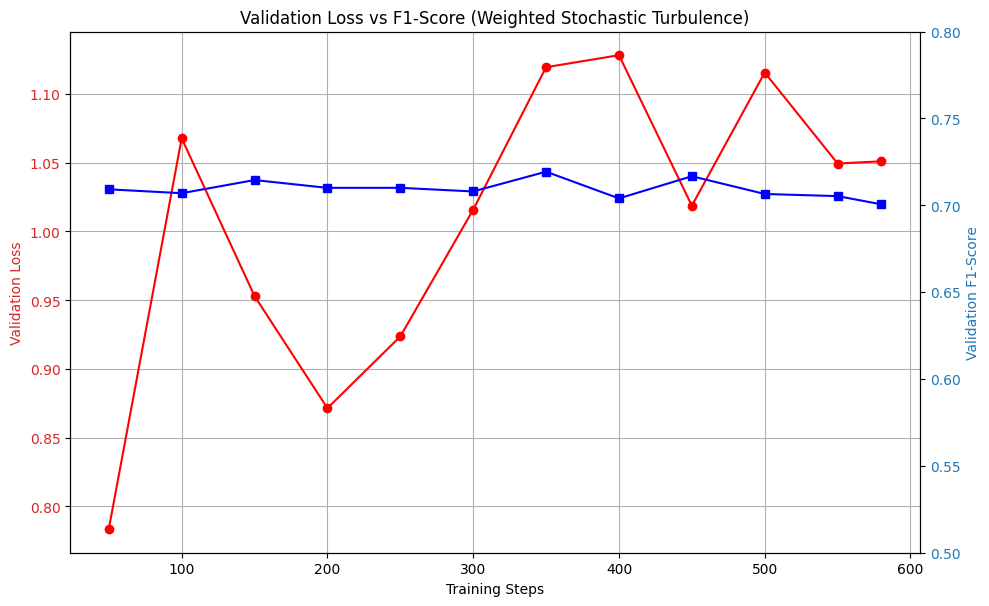

In [33]:
import matplotlib.pyplot as plt

# Lấy lịch sử log của Trainer
log_history = trainer.state.log_history
# Phải đảm bảo lấy những log có chứa cả eval_loss và eval_f1
val_logs = [x for x in log_history if 'eval_loss' in x and 'eval_f1' in x]

# Loại bỏ điểm đánh giá cuối cùng trên tập Test (nếu có, điểm này thường dư ra ở cuối)
if len(val_logs) > 1 and val_logs[-1].get('step') == val_logs[-2].get('step'):
    val_logs = val_logs[:-1]
elif len(val_logs) > (5 * len(train_dataset) // 16 // 50): # Ước lượng số log hợp lý
    val_logs = val_logs[:-1]

steps = [x['step'] for x in val_logs]
val_loss = [x['eval_loss'] for x in val_logs]
val_f1 = [x['eval_f1'] for x in val_logs]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ đường Validation Loss (Trục Y bên trái, màu đỏ)
color1 = 'tab:red'
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Validation Loss', color=color1)
ax1.plot(steps, val_loss, 'ro-', label='Validation Loss')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True)

# Vẽ đường F1-Score (Trục Y bên phải, màu xanh)
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Validation F1-Score', color=color2)
ax2.plot(steps, val_f1, 'bs-', label='F1-Score')
ax2.tick_params(axis='y', labelcolor=color2)

# Giới hạn trục Y cho F1-Score (0.5 đến 0.8) để biểu đồ phản ánh đúng độ ổn định
ax2.set_ylim(0.5, 0.8)

fig.tight_layout()
plt.title('Validation Loss vs F1-Score (Weighted Stochastic Turbulence)')
plt.show()

# Pseudo-labeling (Máy tự gán nhãn cho tập thô)
Sau khi model đã khôn lên, chúng ta bắt nó đi đọc 5,040 bài báo còn lại để gán nhãn. Nhớ là ta có cổng gác: Chỉ lấy bài nào model tự tin
≥
0.85

Inference (Dự đoán)

In [34]:
import torch
import torch.nn.functional as F

# Chuyển model sang chế độ evaluate và ném lên GPU
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

pseudo_labels = []
confidence_scores = []
texts = df_unlabeled['text'].tolist() # Dùng cột text đã được nối từ title và content

# Chạy theo từng batch nhỏ để tránh hết RAM
batch_size = 32
for i in range(0, len(texts), batch_size):
    batch_texts = texts[i : i+batch_size]

    # Tokenize batch
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Tính ra phần trăm tự tin (Softmax probabilities)
    probs = F.softmax(outputs.logits, dim=-1)

    # Lấy nhãn có xác suất cao nhất và điểm số tương ứng
    max_probs, preds = torch.max(probs, dim=-1)

    pseudo_labels.extend(preds.cpu().numpy())
    confidence_scores.extend(max_probs.cpu().numpy())

# Cập nhật kết quả vào DataFrame
df_unlabeled['machine_label'] = pseudo_labels
df_unlabeled['confidence'] = confidence_scores

Tách dữ liệu theo ngưỡng Confidence = 0.85 và Xuất file CSV

In [35]:
# Lọc ra những bài tự tin cao
df_high_conf = df_unlabeled[df_unlabeled['confidence'] >= 0.85]

# Lọc ra những bài tự tin thấp (Cần con người duyệt lại hoặc bỏ qua)
df_low_conf = df_unlabeled[df_unlabeled['confidence'] < 0.85]

# Xuất ra file
df_high_conf.to_csv(f"{DATA_DIR}/pseudo_labeled_5040.csv", index=False)
df_low_conf.to_csv(f"{DATA_DIR}/low_confidence_queue.csv", index=False)

print(f"Số bài đạt chuẩn (>= 0.85): {len(df_high_conf)}")
print(f"Số bài dưới chuẩn (< 0.85): {len(df_low_conf)}")
print(f"Đã lưu thành công vào Google Drive của bạn!")

Số bài đạt chuẩn (>= 0.85): 3194
Số bài dưới chuẩn (< 0.85): 3243
Đã lưu thành công vào Google Drive của bạn!


Gộp Data và Huấn luyện lại để đánh giá Giai đoạn 2

In [40]:
# 1. Gộp tập Train cũ với tập Pseudo-label (những bài >= 0.85)
df_high_conf_clean = df_high_conf[['text', 'machine_label']].rename(columns={'machine_label': 'label'})
df_train_combined = pd.concat([df_train, df_high_conf_clean])

# 2. Tokenize lại tập Train mới
train_combined_dataset = Dataset.from_pandas(df_train_combined)
tokenized_train_combined = train_combined_dataset.map(tokenize_function, batched=True)

# 3. Tính toán lại Class Weights cho tập dữ liệu lai (Quan trọng!)
labels_stage2 = df_train_combined['label'].values
class_weights_stage2 = compute_class_weight(class_weight='balanced', classes=np.unique(labels_stage2), y=labels_stage2)
class_weights_tensor_stage2 = torch.tensor(class_weights_stage2, dtype=torch.float32).to(device)

class CustomTrainerStage2(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor_stage2)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 4. Warm Start: Kế thừa mô hình xịn nhất từ Giai đoạn 1 (thay vì học lại từ đầu)
# Trainer tự động lưu mô hình xịn nhất vào output_dir sau Giai đoạn 1
model_stage2 = AutoModelForSequenceClassification.from_pretrained(f"{DATA_DIR}/distilbert-scrm-risk", num_labels=3)
model_stage2.to(device)

# 5. Điều chỉnh siêu tham số: Học nhẹ nhàng (Micro-Learning Rate) để không hỏng kiến thức cũ
training_args_stage2 = TrainingArguments(
    output_dir=f"{DATA_DIR}/distilbert-scrm-risk-stage2",
    eval_strategy="steps",
    eval_steps=50,
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,               # Tự động xóa checkpoint cũ, chỉ giữ 2 cái gần nhất
    learning_rate=1e-5,               # Giảm một nửa tốc độ học
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,               # Chỉ tinh chỉnh 2 vòng là đủ
    weight_decay=0.1,                 # Giữ nguyên mức phạt chống học vẹt
    warmup_ratio=0.1,
    load_best_model_at_end=True,
)

trainer_stage2 = CustomTrainerStage2(
    model=model_stage2,
    args=training_args_stage2,
    train_dataset=tokenized_train_combined,
    eval_dataset=tokenized_val, # Vẫn dùng tập Val cũ
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Đang tinh chỉnh (Fine-tune) Giai đoạn 2...")
trainer_stage2.train()

# 6. Đánh giá trên tập TEST CŨ (10% Gold Test Set)
print("---")
print("Kết quả đánh giá GIAI ĐOẠN 2 trên tập Test cũ (Để chứng minh Data Augmentation Gain):")
test_results_stage2 = trainer_stage2.evaluate(eval_dataset=tokenized_test)
print(test_results_stage2)

Map:   0%|          | 0/5041 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Đang tinh chỉnh (Fine-tune) Giai đoạn 2...


Step,Training Loss,Validation Loss,Accuracy,F1
50,0.206813,0.777894,0.683983,0.701452
100,0.241206,0.866463,0.705628,0.718562
150,0.182338,1.042134,0.683983,0.700226
200,0.197594,1.074108,0.701299,0.710517
250,0.255158,1.047683,0.670996,0.689399
300,0.265142,1.049502,0.688312,0.706204
350,0.165207,1.159567,0.705628,0.720393
400,0.170334,1.177113,0.692641,0.704579
450,0.126589,1.234320,0.679654,0.698119
500,0.193908,1.211262,0.696970,0.712921


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

---
Kết quả đánh giá GIAI ĐOẠN 2 trên tập Test cũ (Để chứng minh Data Augmentation Gain):


Training Loss,Validation Loss,Step,Accuracy,F1
0.169792,0.847048,632,0.714286,0.724126


{'eval_loss': 0.847047746181488, 'eval_accuracy': 0.7142857142857143, 'eval_f1': 0.7241259366415813}


In [41]:
import pandas as pd
import numpy as np

# Đường dẫn thư mục (giữ nguyên như trong Colab của bạn)
DATA_DIR = "/content/drive/MyDrive/SCRM_Data"
input_file = f"{DATA_DIR}/pseudo_labeled_5040.csv"

# 1. Đọc dữ liệu máy đã dán nhãn
print("Đang đọc dữ liệu từ:", input_file)
df = pd.read_csv(input_file)

# Khởi tạo list chứa các sample
samples = []

# 2. Lấy mẫu ngẫu nhiên phân tầng (Stratified Random Sampling) - 50 bài mỗi nhãn
for label in [0, 1, 2]:
    # Lọc các bài thuộc nhãn này
    df_label = df[df['machine_label'] == label]

    # Lấy đúng 50 bài, hoặc lấy tất cả nếu số lượng ít hơn 50
    n_sample = min(50, len(df_label))
    sampled = df_label.sample(n=n_sample, random_state=42)
    samples.append(sampled)

    print(f"Nhãn {label}: Lấy {n_sample} bài (Tổng có {len(df_label)} bài)")

# 3. Gộp 150 bài và xáo trộn ngẫu nhiên (để lúc gán bạn không bị thiên kiến)
df_qc = pd.concat(samples).sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Lưu lại file Answer Key (chứa nhãn của máy để sau này đối chiếu)
key_output_file = f"{DATA_DIR}/QC_answer_key_150.csv"
df_qc.to_csv(key_output_file, index=False)
print(f"\nĐã lưu Answer Key (đáp án của máy) tại: {key_output_file}")

# 5. Tạo file Mù (Blind Annotation) cho chuyên gia gán
# Ẩn đi cột machine_label và confidence
df_blind = df_qc.copy()
df_blind['human_label'] = "" # Chỗ để bạn điền nhãn bằng tay
df_blind = df_blind.drop(columns=['machine_label', 'confidence'])

# 6. Xuất ra file Excel để bạn dễ mở lên đọc và gán nhãn
blind_output_file = f"{DATA_DIR}/QC_blind_annotation_150.xlsx"
df_blind.to_excel(blind_output_file, index=False)
print(f"Đã lưu file gán nhãn mù tại: {blind_output_file}")


Đang đọc dữ liệu từ: /content/drive/MyDrive/SCRM_Data/pseudo_labeled_5040.csv
Nhãn 0: Lấy 50 bài (Tổng có 2062 bài)
Nhãn 1: Lấy 50 bài (Tổng có 783 bài)
Nhãn 2: Lấy 50 bài (Tổng có 349 bài)

Đã lưu Answer Key (đáp án của máy) tại: /content/drive/MyDrive/SCRM_Data/QC_answer_key_150.csv
Đã lưu file gán nhãn mù tại: /content/drive/MyDrive/SCRM_Data/QC_blind_annotation_150.xlsx


In [44]:
import pandas as pd
import spacy

print("Đang tải mô hình NER (spaCy)...")
nlp = spacy.load('en_core_web_sm')

DATA_DIR = "/content/drive/MyDrive/SCRM_Data"
input_file = f"{DATA_DIR}/pseudo_labeled_5040.csv"
df = pd.read_csv(input_file)

# Đã bổ sung thêm một số từ khóa thị trường gây nhiễu
negative_keywords = ['cut forecast', 'short of plan', 'import fewer', 'demand forecast', 'market analysis', 'stock price', 'earnings', 'revenue', 'sales expectations', 'profit margin', 'economic conditions']
disruption_keywords = ['delay', 'disruption', 'shortage', 'strike', 'congestion', 'port closed', 'halt', 'cyberattack', 'cyber attack']

survivors = []

print("Đang chạy Màng Lọc Heuristics...")
for idx, row in df.iterrows():
    machine = int(row['machine_label'])
    conf = float(row['confidence'])
    text_lower = str(row['text']).lower()

    keep = True

    # 1. HẠ THRESHOLD VỀ 0.85 CHO TẤT CẢ (Giữ nguyên vẹn 3194 bài ban đầu)
    if conf < 0.85:
        continue

    # 2. LUẬT TỪ KHÓA CHO NHÃN 1
    if machine == 1:
        has_negative = any(kw in text_lower for kw in negative_keywords)
        has_disruption = any(kw in text_lower for kw in disruption_keywords)
        # Nếu chỉ bàn chuyện tài chính thị trường mà không có đứt gãy vật lý -> XÓA
        if has_negative and not has_disruption:
            keep = False

    # 3. LUẬT THỜI GIAN NER CHO NHÃN 2
    if machine == 2:
        doc = nlp(str(row['text']))
        date_ents = [ent.text.lower() for ent in doc.ents if ent.label_ == 'DATE']

        has_past_time = False
        for d in date_ents:
            if '2020' in d or '2021' in d or '2022' in d or 'last year' in d or 'previous year' in d:
                has_past_time = True
                break

        if 'cyberattack' in text_lower:
            has_past_time = True

        if has_past_time:
            keep = False

    if keep:
        survivors.append(row)

df_refined = pd.DataFrame(survivors)
print(f"Tổng số bài SỐNG SÓT: {len(df_refined)}")
if len(df_refined) > 0:
    print(df_refined['machine_label'].value_counts())

# Lưu lại file
output_file = f"{DATA_DIR}/pseudo_labeled_refined.csv"
df_refined.to_csv(output_file, index=False)
print(f"\nĐã lưu tập Refined tại: {output_file}")

Đang tải mô hình NER (spaCy)...
Đang chạy Màng Lọc Heuristics...
Tổng số bài SỐNG SÓT: 3004
machine_label
0    2062
1     712
2     230
Name: count, dtype: int64

Đã lưu tập Refined tại: /content/drive/MyDrive/SCRM_Data/pseudo_labeled_refined.csv
